In [1]:
import sys

print(sys.executable)

d:\Masai\zepto-data-ai-platform\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [26]:
df = pd.read_csv("../data_pipeline/cleaned_books.csv")

In [27]:
df.head()

,title,category,price_gbp,rating,in_stock,price_inr
0,It's Only the Himalayas,Travel,45.17,2,True,4765.44
1,Full Moon over Noahâs Ark: An Odyssey to Mou...,Travel,49.43,4,True,5214.86
2,See America: A Celebration of Our National Par...,Travel,48.87,3,True,5155.78
3,Vagabonding: An Uncommon Guide to the Art of L...,Travel,36.94,2,True,3897.17
4,Under the Tuscan Sun,Travel,37.33,3,True,3938.31


In [28]:
df.tail()

,title,category,price_gbp,rating,in_stock,price_inr
64,While You Were Mine,Historical Fiction,41.32,5,True,4359.26
65,The Secret Healer,Historical Fiction,34.56,3,True,3646.08
66,Starlark,Historical Fiction,25.83,3,True,2725.06
67,Lost Among the Living,Historical Fiction,27.70,4,True,2922.35
68,A Spy's Devotion (The Regency Spies of London #1),Historical Fiction,16.97,5,True,1790.33


In [29]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 69
Columns: 6


In [30]:
df.shape

(69, 6)

In [34]:
print(df.columns.tolist())

['title', 'category', 'price_gbp', 'rating', 'in_stock', 'price_inr']


In [94]:
df.columns

Index(['title', 'category', 'price_gbp', 'rating', 'in_stock', 'price_inr'], dtype='str')

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      69 non-null     str    
 1   category   69 non-null     str    
 2   price_gbp  69 non-null     float64
 3   rating     69 non-null     int64  
 4   in_stock   69 non-null     bool   
 5   price_inr  69 non-null     float64
dtypes: bool(1), float64(2), int64(1), str(2)
memory usage: 2.9 KB


In [37]:
df.isnull().sum()

title        0
category     0
price_gbp    0
rating       0
in_stock     0
price_inr    0
dtype: int64

In [69]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [70]:
df.describe()

,price_gbp,rating,price_inr
count,69.000000,69.000000,69.000000
mean,33.731884,3.014493,3558.714203
std,14.099470,1.419328,1487.493916
min,10.690000,1.000000,1127.790000
25%,21.070000,2.000000,2222.890000
50%,30.540000,3.000000,3221.970000
75%,45.840000,4.000000,4836.120000
max,59.480000,5.000000,6275.140000


In [55]:
df["category"].value_counts()

category
Mystery               32
Historical Fiction    26
Travel                11
Name: count, dtype: int64

In [56]:
df["category"].value_counts(normalize=True).round(2) * 100

category
Mystery               46.0
Historical Fiction    38.0
Travel                16.0
Name: proportion, dtype: float64

In [41]:
df["category"].value_counts(normalize=True).mul(100).round(2)

category
Mystery               46.38
Historical Fiction    37.68
Travel                15.94
Name: proportion, dtype: float64

In [42]:
df.groupby("category")["price_gbp"].mean().round(2)

category
Historical Fiction    33.64
Mystery               31.72
Travel                39.79
Name: price_gbp, dtype: float64

In [72]:
avg_price = df.groupby("category")["price_gbp"].mean()

print("Most expensive category:",
      avg_price.idxmax())

print("Average price:",
      round(avg_price.max(), 2))

Most expensive category: Travel
Average price: 39.79


In [43]:
df.groupby("category")["rating"].mean().round(2)

category
Historical Fiction    3.23
Mystery               2.94
Travel                2.73
Name: rating, dtype: float64

In [74]:
avg_rating = df.groupby("category")["rating"].mean().round(2)

avg_rating

category
Historical Fiction    3.23
Mystery               2.94
Travel                2.73
Name: rating, dtype: float64

In [75]:
print("Highest rated category:", avg_rating.idxmax())
print("Average rating:", avg_rating.max())

Highest rated category: Historical Fiction
Average rating: 3.23


In [76]:
print("Highest rated category:", avg_rating.idxmax())
print("Average rating:", avg_rating.max())

Highest rated category: Historical Fiction
Average rating: 3.23


In [45]:
df["price_gbp"].min()

np.float64(10.69)

In [46]:
df["price_gbp"].max()

np.float64(59.48)

In [47]:
df["price_gbp"].describe()

count    69.000000
mean     33.731884
std      14.099470
min      10.690000
25%      21.070000
50%      30.540000
75%      45.840000
max      59.480000
Name: price_gbp, dtype: float64

In [50]:
df["in_stock"].value_counts()

in_stock
True    69
Name: count, dtype: int64

In [77]:
df.groupby("category")["in_stock"].mean()

category
Historical Fiction    1.0
Mystery               1.0
Travel                1.0
Name: in_stock, dtype: float64

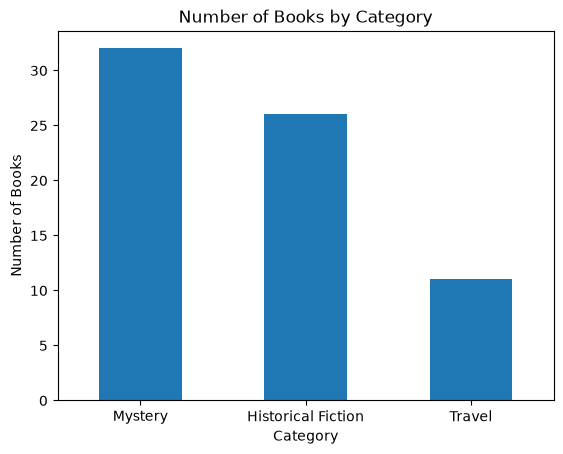

In [78]:
category_counts = df["category"].value_counts()

category_counts.plot(kind="bar")

plt.title("Number of Books by Category")
plt.xlabel("Category")
plt.ylabel("Number of Books")

plt.xticks(rotation=0)

plt.show()

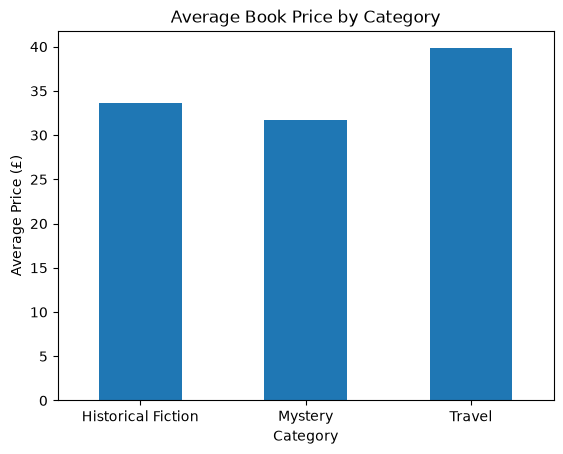

In [79]:
avg_price = df.groupby("category")["price_gbp"].mean()

avg_price.plot(kind="bar")

plt.title("Average Book Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (£)")

plt.xticks(rotation=0)

plt.show()

In [51]:
df["rating"].value_counts().sort_index()

rating
1    14
2    12
3    16
4    13
5    14
Name: count, dtype: int64

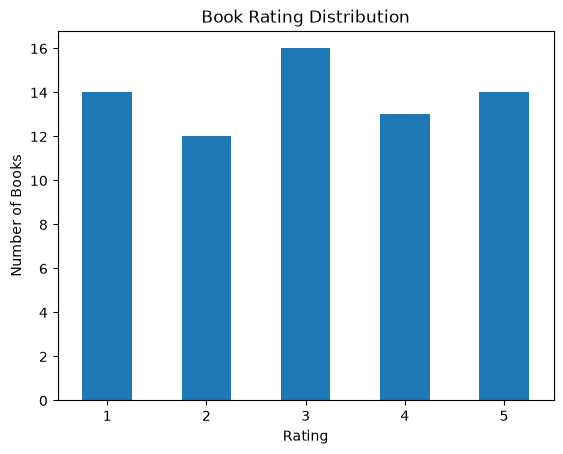

In [82]:
df["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.xticks(rotation=0)

plt.show()

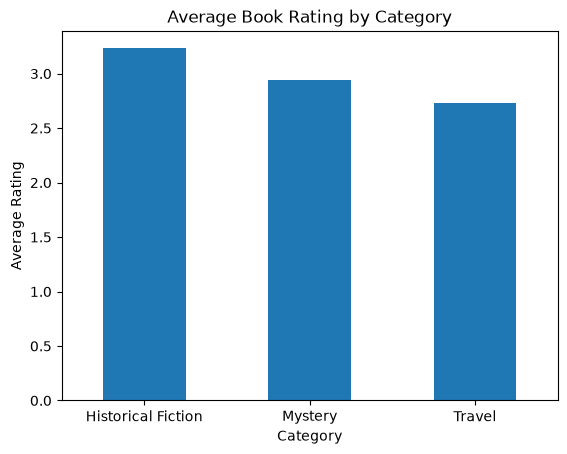

In [84]:
avg_rating = df.groupby("category")["rating"].mean()

avg_rating.plot(kind="bar")

plt.title("Average Book Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.xticks(rotation=0)

plt.show()

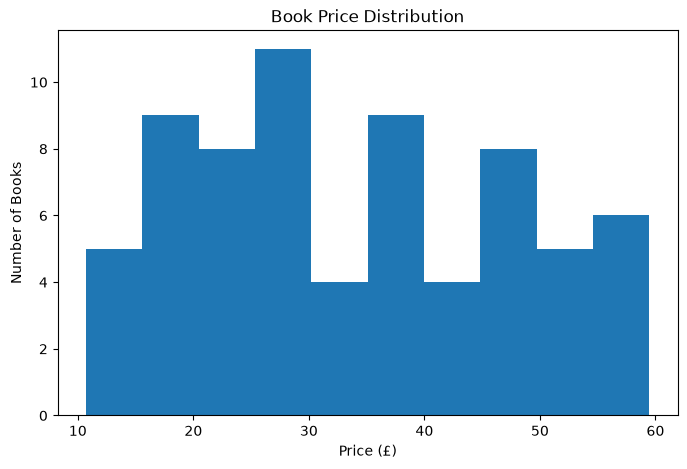

In [85]:
plt.figure(figsize=(8, 5))

plt.hist(df["price_gbp"], bins=10)

plt.title("Book Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

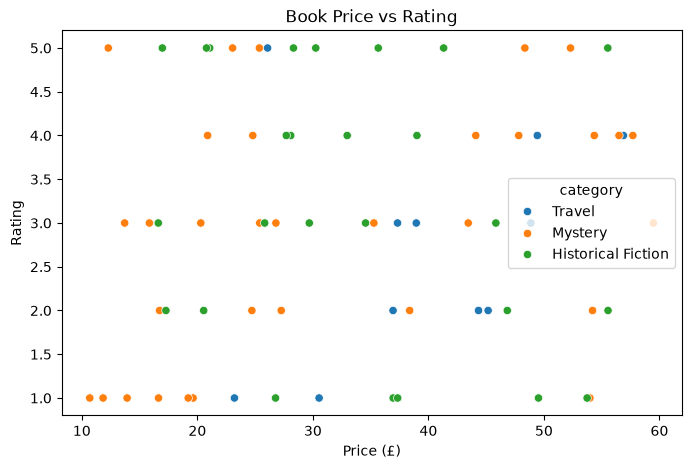

In [87]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="price_gbp",
    y="rating",
    hue="category"
)

plt.title("Book Price vs Rating")
plt.xlabel("Price (£)")
plt.ylabel("Rating")

plt.show()

In [88]:
df[["price_gbp", "price_inr", "rating"]].corr()

,price_gbp,price_inr,rating
price_gbp,1.000000,1.000000,0.106752
price_inr,1.000000,1.000000,0.106752
rating,0.106752,0.106752,1.000000


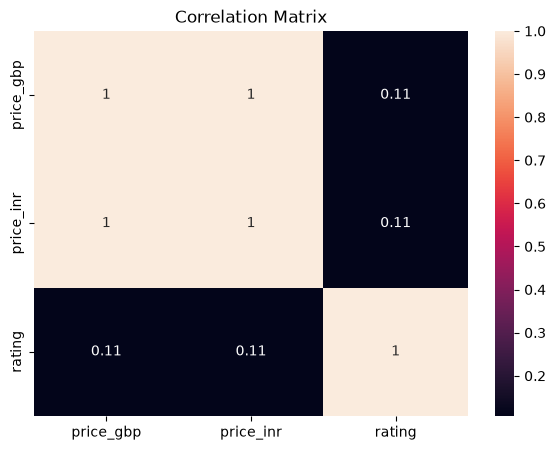

In [89]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    df[["price_gbp", "price_inr", "rating"]].corr(),
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

In [90]:
category_summary = df.groupby("category").agg(
    book_count=("title", "count"),
    average_price_gbp=("price_gbp", "mean"),
    average_rating=("rating", "mean")
).round(2)

category_summary

,book_count,average_price_gbp,average_rating
category,,,
Historical Fiction,26,33.64,3.23
Mystery,32,31.72,2.94
Travel,11,39.79,2.73


In [91]:
df.sort_values("rating", ascending=False)[
    ["title", "category", "rating", "price_gbp"]
].head(10)

,title,category,rating,price_gbp
33,The Silkworm (Cormoran Strike #2),Mystery,5,23.05
28,What Happened on Beale Street (Secrets of the ...,Mystery,5,25.37
29,The Bachelor Girl's Guide to Murder (Herringfo...,Mystery,5,52.30
19,A Time of Torment (Charlie Parker #14),Mystery,5,48.35
10,"1,000 Places to See Before You Die",Travel,5,26.08
56,The Passion of Dolssa,Historical Fiction,5,28.32
58,Voyager (Outlander #3),Historical Fiction,5,21.07
59,The Red Tent,Historical Fiction,5,35.66
64,While You Were Mine,Historical Fiction,5,41.32
63,Between Shades of Gray,Historical Fiction,5,20.79


In [93]:
df.sort_values("price_gbp", ascending=False)[
    ["title", "category", "rating", "price_gbp"]
].head(10)

,title,category,rating,price_gbp
25,Boar Island (Anna Pigeon #19),Mystery,3,59.48
38,The No. 1 Ladies' Detective Agency (No. 1 Ladi...,Mystery,4,57.70
7,A Year in Provence (Provence #1),Travel,4,56.88
13,The Past Never Ends,Mystery,4,56.50
60,The Last Painting of Sara de Vos,Historical Fiction,2,55.55
45,A Flight of Arrows (The Pathfinders #2),Historical Fiction,5,55.53
22,Murder at the 42nd Street Library (Raymond Amb...,Mystery,4,54.36
16,The Last Mile (Amos Decker #2),Mystery,2,54.21
42,1st to Die (Women's Murder Club #1),Mystery,1,53.98
43,Tipping the Velvet,Historical Fiction,1,53.74


In [60]:
df["in_stock"].value_counts()

in_stock
True    69
Name: count, dtype: int64

In [61]:
df["in_stock"].value_counts(normalize=True).round(2) * 100

in_stock
True    100.0
Name: proportion, dtype: float64

In [62]:
pd.crosstab(df["category"], df["in_stock"])

in_stock,True
category,
Historical Fiction,26
Mystery,32
Travel,11


In [63]:
df[["price_gbp", "rating"]].corr()

,price_gbp,rating
price_gbp,1.000000,0.106752
rating,0.106752,1.000000


In [95]:
category_summary.to_csv(
    "../data_pipeline/category_summary.csv",
    index=True
)

print("Category summary saved successfully")

Category summary saved successfully


# EDA Insights

## Dataset

The dataset contains books from three selected categories:

- Travel
- Mystery
- Historical Fiction

## Category Analysis

The category distribution was analyzed using book counts and percentages.

## Price Analysis

Average book prices were calculated for each category to identify
which category has the highest average price.

## Rating Analysis

Average ratings were calculated for each category to compare
book ratings across categories.

## Availability Analysis

Book availability was analyzed using the `in_stock` column.

## Visualization

The analysis includes:

- Number of books by category
- Average price by category
- Average rating by category
- Rating distribution
- Price distribution
- Price vs rating
- Correlation heatmap

## Conclusion

The EDA provides an understanding of the distribution,
pricing, ratings, and availability of books in the selected
categories.